# Classificação Binária de Notícias em Português (Real vs Fake)

## Introdução
Este notebook apresenta uma análise de classificação binária de notícias em português usando o Fake.br-Corpus, com foco em distinguir notícias reais (`label = 0`) de notícias falsas (`label = 1`).

A proposta combina duas frentes metodológicas:
- pipeline tradicional de NLP/ML (preprocessamento, engenharia de atributos e modelagem clássica);
- pipeline baseado em Transformers para comparação de desempenho e robustez.

## Objetivos
- consolidar e validar o corpus no ambiente Google Colab;
- documentar etapas de limpeza e transformação textual com rastreabilidade;
- produzir uma base pronta para experimentos supervisionados e avaliação comparativa.

## Estrutura do Notebook
- 0. Inicialização do ambiente e montagem do Google Drive;
- 1. Configuração de dependências e utilitários de exibição;
- 2. Consolidação e engenharia do corpus;
- 3. Análise exploratória (EDA);
- 4. Pré-processamento textual e análise de impacto no tamanho dos textos.

## Observações de Reprodutibilidade
- caminho esperado do dataset: `/content/drive/MyDrive/Fake.br-Corpus/`;
- a execução deve seguir a ordem das seções para evitar variáveis incompletas no estado da sessão.

## 0. Inicialização do Ambiente

### 0.1. Montagem do Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Configuração do Ambiente e Dependências
Nesta seção, realizamos a instalação e o carregamento de todas as dependências necessárias para a execução do pipeline de Processamento de Linguagem Natural (NLP) e manipulação de dados.

### 1.1. Instalação de Pacotes e Importação de Bibliotecas

In [2]:
# Instalação e download de modelos de NLP necessários para o processamento em português
!python -m spacy download pt_core_news_sm

import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textwrap import fill
from IPython.display import HTML, display

%matplotlib inline

# Download do dicionário de stopwords do NLTK
nltk.download('stopwords')

#
nltk.download('wordnet')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 48.3 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# Configuração global de exibição textual
LARGURA_TEXTO_PADRAO = 110
MAX_COLWIDTH_DF = 140

pd.set_option('display.max_colwidth', MAX_COLWIDTH_DF)

def wrap_texto(texto, largura=LARGURA_TEXTO_PADRAO):
    if pd.isna(texto):
        return ''
    return fill(str(texto), width=largura)

# Aplica quebra de linha nas células de tabelas exibidas no notebook
display(HTML(f"""
<style>
table.dataframe td {{
  white-space: pre-wrap;
  word-break: break-word;
  max-width: {LARGURA_TEXTO_PADRAO}ch;
}}
</style>
"""))

## 2. Consolidação e Engenharia do Corpus (Fake.br-Corpus)
O bloco a seguir valida o ambiente de diretórios do Google Drive e encapsula a lógica de extração textual e síncrona dos 25 metadados oficiais do corpus linguístico.

### 2.1. Validação de Caminhos no Google Drive

In [4]:
basepath = '/content/drive/MyDrive/Fake.br-Corpus/full_texts/'

if not os.path.exists(basepath):
    print("Erro Crítico: A pasta 'full_texts' não foi encontrada no seu Drive. Verifique o caminho.")
    exit()

### 2.2. Construção Programática da Base Consolidada

In [ ]:
def construir_base_dados():
    """
    Realiza a leitura iterativa do Fake.br-Corpus, mapeando de forma síncrona
    as notícias completas e suas respectivas linhas de metadados associados.
    """
    lista_registros = []

    def processar_pasta(pasta_txt, pasta_meta, label_classificacao):
        if not os.path.exists(pasta_txt):
            print(f"Erro Crítico: A pasta {pasta_txt} não foi encontrada no seu Drive.")
            return

        arquivos = sorted([f for f in os.listdir(pasta_txt) if f.endswith('.txt')])
        print(f"Total de notícias encontradas nesta pasta: {len(arquivos)}")

        # Mapeamento exato dos 25 metadados oficiais fornecidos pelo corpus estruturado
        nomes_metadados = [
            'autor', 'link_fonte', 'categoria', 'data_publicacao', 'num_tokens',
            'num_palavras_sem_pontuacao', 'num_types', 'num_links_internos',
            'num_palavras_maiusculas', 'num_verbos', 'num_verbos_subj_imperativo',
            'num_substantivos', 'num_adjetivos', 'num_adverbios', 'num_verbos_modais',
            'num_pronomes_sing_1_2', 'num_pronomes_plu_1', 'num_pronomes', 'pausabilidade',
            'num_caracteres', 'comprimento_medio_sentenca', 'comprimento_medio_palavra',
            'porcentagem_erros_ortograficos', 'emotividade', 'diversidade_lexical'
        ]

        for arquivo in arquivos:
            caminho_arquivo_txt = os.path.join(pasta_txt, arquivo)
            arquivo_sem_ext = arquivo.replace('.txt', '')
            caminho_arquivo_meta = os.path.join(pasta_meta, arquivo_sem_ext + '-meta.txt')

            # Tratamento de fallback de encoding para salvaguardar acentuações em português
            texto_noticia = ""
            for enc in ['utf-8-sig', 'latin-1']:
                try:
                    with open(caminho_arquivo_txt, 'r', encoding=enc) as f:
                        texto_noticia = f.read().strip()
                    break
                except UnicodeDecodeError:
                    continue

            metadados_extraidos = {coluna: None for coluna in nomes_metadados}

            if os.path.exists(caminho_arquivo_meta):
                conteudo_meta = ""
                for enc in ['utf-8-sig', 'latin-1']:
                    try:
                        with open(caminho_arquivo_meta, 'r', encoding=enc) as f:
                            conteudo_meta = f.read()
                        break
                    except UnicodeDecodeError:
                        continue

                if conteudo_meta:
                    linhas_meta = [linha.strip() for linha in conteudo_meta.splitlines()]
                    for i in range(min(len(linhas_meta), 25)):
                        if linhas_meta[i]:
                            coluna_atual = nomes_metadados[i]
                            metadados_extraidos[coluna_atual] = linhas_meta[i]

            registro = {
                'id_original': arquivo_sem_ext,
                'texto_completo': texto_noticia,
                'label': label_classificacao
            }
            registro.update(metadados_extraidos)
            lista_registros.append(registro)

    print(">> Carregando instâncias de notícias FALSAS...")
    processar_pasta(basepath + 'fake', basepath + 'fake-meta-information', label_classificacao=1)

    print(">> Carregando instâncias de notícias VERDADEIRAS...")
    processar_pasta(basepath + 'true', basepath + 'true-meta-information', label_classificacao=0)

    return pd.DataFrame(lista_registros)

# 1. Executa a função
df = construir_base_dados()

# 2. Exporta para CSV com tratamento de acentuação (Excel friendly)
caminho_saida = 'base_dados_tcc.csv'
df.to_csv(caminho_saida, index=False, encoding='utf-8-sig', sep=';')

print(f"Base de dados exportada com sucesso para: {caminho_saida}")

## 3. Análise Exploratória e Qualidade de Dados (EDA)
Abaixo, carregamos o arquivo final em disco para garantir a persistência dos dados brutos e iniciamos as verificações de balanceamento de classes.

### 3.1. Carregamento do Dataset e Inspeção Inicial

In [6]:
df = pd.read_csv('/content/drive/MyDrive/Fake.br-Corpus/fake.br-full_texts.csv')
df = df[['label', 'texto_completo', 'categoria']]
print(df['label'].value_counts())
print("Dimensões do Dataset:", df.shape)

label
1    3600
0    3600
Name: count, dtype: int64
Dimensões do Dataset: (7200, 3)


### 3.2. Distribuição das Classes e Categorias

#### 3.2.1. Distribuição de Classes (Fake vs. Real)
- Gráfico de barras mostrando a proporção de notícias reais e falsas.

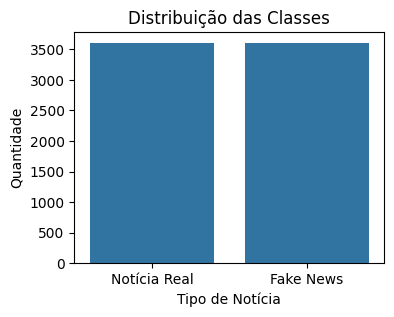

In [7]:
# Visualização gráfica da distribuição balanceada das classes
plt.figure(figsize=(4,3))
ax = sns.countplot(x=df['label'])
plt.xticks([0, 1], ['Notícia Real', 'Fake News'])
ax.set(xlabel='Tipo de Notícia', ylabel='Quantidade', title='Distribuição das Classes')
plt.show()

#### 3.2.2. Distribuição por Categoria
- Gráfico de barras mostrando a distribuição de notícias por categoria (Política, Esporte, Entretenimento, etc.).

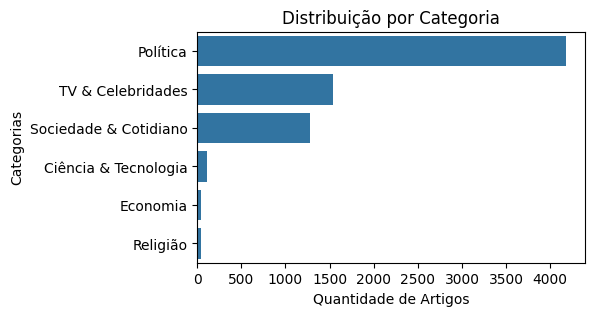

In [8]:
# Distribuição volumétrica dos documentos pelas categorias linguísticas
plt.figure(figsize=(5,3))
sns.countplot(y=df['categoria'])
plt.xlabel('Quantidade de Artigos')
plt.ylabel('Categorias')
plt.title('Distribuição por Categoria')
plt.yticks(ticks=[0, 1, 2, 3, 4, 5], labels=['Política', 'TV & Celebridades', 'Sociedade & Cotidiano', 'Ciência & Tecnologia', 'Economia', 'Religião'])
plt.show()

#### 3.2.3. Análise de Comprimento dos Textos
- Boxplot ou histograma mostrando a distribuição do número de palavras por notícia.

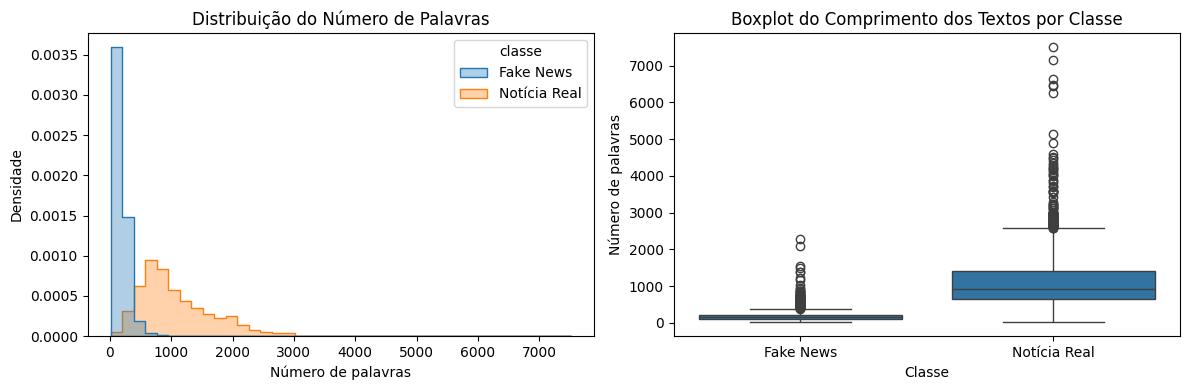

,count,mean,std,min,25%,50%,75%,max
classe,,,,,,,,
Fake News,3600.0,185.89,127.63,9.0,115.0,157.0,224.0,2288.0
Notícia Real,3600.0,1100.29,682.97,20.0,642.0,918.0,1416.0,7517.0


In [9]:
# Métrica de comprimento: número de palavras por notícia
df['num_palavras_texto'] = df['texto_completo'].fillna('').astype(str).str.split().str.len()

# Mapeamento para rótulos legíveis no gráfico
mapa_rotulos = {0: 'Notícia Real', 1: 'Fake News'}
df['classe'] = df['label'].map(mapa_rotulos)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma por classe
sns.histplot(
    data=df,
    x='num_palavras_texto',
    hue='classe',
    bins=40,
    element='step',
    stat='density',
    common_norm=False,
    alpha=0.35,
    ax=axes[0]
 )
axes[0].set_title('Distribuição do Número de Palavras')
axes[0].set_xlabel('Número de palavras')
axes[0].set_ylabel('Densidade')

# Boxplot por classe
sns.boxplot(data=df, x='classe', y='num_palavras_texto', ax=axes[1])
axes[1].set_title('Boxplot do Comprimento dos Textos por Classe')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Número de palavras')

plt.tight_layout()
plt.show()

# Estatísticas descritivas rápidas
display(df.groupby('classe')['num_palavras_texto'].describe().round(2))

## 4. Pipeline de Limpeza de Texto (Data Cleaning & Stopwords Fusion)
Nesta fase, removemos valores nulos residuais e criamos a união de stopwords das bibliotecas NLTK e SpaCy para o pré-processamento avançado.

### 4.1. Diagnóstico de Nulos e União de Stopwords

In [10]:
# Tem dados nulos ou em branco?
print("Valores ausentes:\n", df.isna().sum())

# All Stopwords
nlp = spacy.load('pt_core_news_sm')
stopwords_spacy = nlp.Defaults.stop_words
stopwords_nltk = stopwords.words('portuguese')
all_stopwords = list(stopwords_spacy.union(set(stopwords_nltk)))
print(f"Total unificado de Stopwords para a língua portuguesa: {len(all_stopwords)}")

Valores ausentes:
 label                 0
texto_completo        0
categoria             0
num_palavras_texto    0
classe                0
dtype: int64
Total unificado de Stopwords para a língua portuguesa: 500


### 4.2. Inicialização do Lematizador

In [ ]:
lemma=WordNetLemmatizer()

### 4.3. Função de Limpeza Textual e Aplicação no Dataset

In [12]:
def text_cleaning(text):

  text = '' if pd.isna(text) else str(text)

  # Convertendo texto para minúsculas
  text = text.lower()

  # Remove caracteres especiais preservando letras acentuadas e dígitos
  text = re.sub(r'[-()"#/@;:<>{}`+=~|.!?,]', ' ', text)

  # Normaliza todos os espaços em branco (incluindo tabs/quebras)
  text = re.sub(r'\s+', ' ', text).strip()

  # Removendo stopwords e aplicando lematização sem gerar espaços duplicados
  tokens_limpos = []
  for word in text.split():
    if word not in all_stopwords:
      tokens_limpos.append(lemma.lemmatize(word))

  return ' '.join(tokens_limpos)

# Execução da limpeza de texto criando a feature limpa
df['clean_text'] = df['texto_completo'].apply(text_cleaning)

# Verificação rápida de qualidade: não deve haver espaços múltiplos
multiplos_espacos = df['clean_text'].str.contains(r'\s{2,}', regex=True, na=False).sum()
print(f"Registros com múltiplos espaços em clean_text (NAO FUNCIONA AINDA): {multiplos_espacos}")

df.head()

Registros com múltiplos espaços em clean_text (NAO FUNCIONA AINDA): 0


,label,texto_completo,categoria,num_palavras_texto,classe,clean_text
0,1,"Kátia Abreu diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar.\t\n\nA senadora Kátia Abreu (sem partido-TO) diss...",politica,182,Fake News,kátia abreu colocar expulsão moldura reclamar senadora kátia abreu partido to disse expulsão pmdb resultado ação cúpula atual legenda op...
1,1,"Dr. Ray peita Bolsonaro, chama-o de conservador fake em entrevista a Danilo Gentili e divide a direita.\n\nEste site vem avisando Jair...",politica,253,Fake News,dr ray peita bolsonaro chama conservador fake entrevista danilo gentili divide site avisando jair bolsonaro deveria abandonar pauta es...
2,1,Reinaldo Azevedo desmascarado pela Polícia Federal. O mais ferrenho crítico do presidenciável Jair Bolsonaro foi desmascarado em um gram...,politica,273,Fake News,reinaldo azevedo desmascarado polícia federal ferrenho crítico presidenciável jair bolsonaro desmascarado grampo telefônico conversas ir...
3,1,"Relatório assustador do BNDES mostra dinheiro público DO BRASIL jorrando em países comunistas. . Um relatório intitulado ""BNDES: Transf...",politica,573,Fake News,relatório assustador bndes mostra dinheiro público brasil jorrando países comunistas relatório intitulado bndes transformado robin hood ...
4,1,"Radialista americano fala sobre o PT: ""Eles vendem ilusão ao povo brasileiro e só pensam em se divertir no sítio"". O radialista america...",politica,119,Fake News,radialista americano fala pt vendem ilusão brasileiro pensam divertir sítio radialista americano alex jones chorou falar crianças saúde ...


### 4.4. Exemplo Sequencial de Pré-processamento (Antes e Depois)

In [13]:
# Seleciona um texto real do corpus para demonstração
texto_exemplo = df['texto_completo'].dropna().astype(str).iloc[0]
num_palavras_original = len(texto_exemplo.split())


print(f"Texto Original (palavras: {num_palavras_original}):\n")
print(wrap_texto(texto_exemplo))

Texto Original (palavras: 182):

Kátia Abreu diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar.    A senadora Kátia
Abreu (sem partido-TO) disse que sua expulsão do PMDB foi resultado de uma ação da cúpula atual da legenda
que, segundo ela, é oportunista.  “Amanhã eu vou botar numa moldura dourada a minha expulsão, porque das mãos
de onde veio, é um atestado de boa conduta para o meu currículo. Essas pessoas que me expulsaram não servem ao
país. Eles se servem do país em seus benefícios próprios”, disse Kátia Abreu.  Ué, mas se a expulsão é algo
tão bom para seu currículo, por que tanta choradeira, Kátia?  Sabemos o motivo. Provavelmente Kátia não tem
valor para o PT, partido que já deveria tê-la absorvido. Ao que parece o PT gostava de Kátia somente se ela
ficasse entrincheirada dentro do PMDB.  Ou seja, isso é se rebaixar demais. Resta a Kátia ficar chorando as
pitangas por todos os cantos.  Em tempo: até o momento o PT não cadastrou Kátia Abreu em suas fileir

In [14]:
# Aplica a função de limpeza ao texto de exemplo
texto_limpo_exemplo = text_cleaning(texto_exemplo).strip()
num_palavras_limpo = len(texto_limpo_exemplo.split())
compactacao_pct = 0 if num_palavras_original == 0 else ((num_palavras_original - num_palavras_limpo) / num_palavras_original) * 100

print(f"\nTexto Limpo (palavras: {num_palavras_limpo} | compactação: {compactacao_pct:.1f}%):\n")
print(wrap_texto(texto_limpo_exemplo))


Texto Limpo (palavras: 81 | compactação: 55.5%):

kátia abreu colocar expulsão moldura reclamar senadora kátia abreu partido to disse expulsão pmdb resultado
ação cúpula atual legenda oportunista “amanhã vou botar moldura dourada expulsão mãos veio atestado conduta
currículo pessoas expulsaram servem país servem país benefícios próprios” disse kátia abreu ué expulsão
currículo choradeira kátia sabemos motivo provavelmente kátia pt partido deveria tê la absorvido pt gostava
kátia ficasse entrincheirada pmdb rebaixar resta kátia ficar chorando pitanga canto pt cadastrou kátia abreu
fileiras situação patética ex ministra agricultura dilma


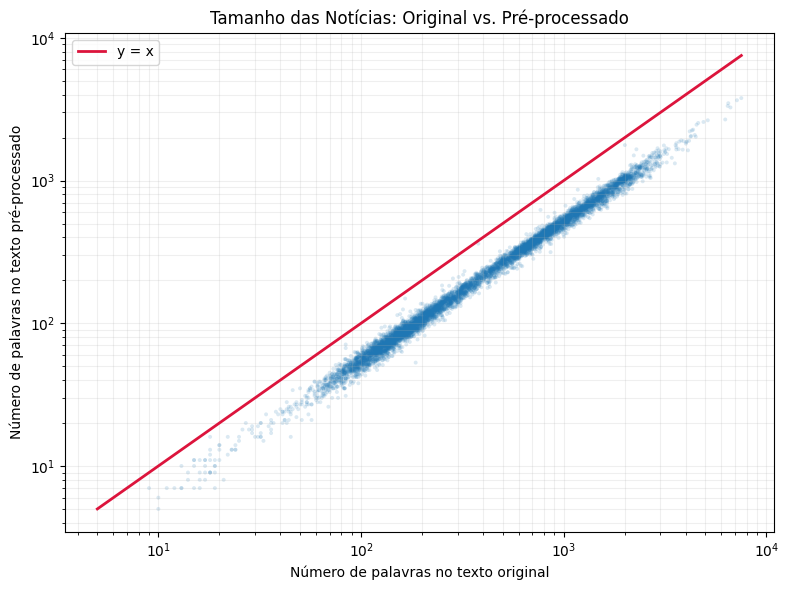

Redução média de tamanho no corpus: 47.3%


In [15]:
# Comparação de tamanho para todos os registros: original vs. pré-processado
if 'num_palavras_texto' not in df.columns:
    df['num_palavras_texto'] = df['texto_completo'].fillna('').astype(str).str.split().str.len()

if 'clean_text' not in df.columns:
    df['clean_text'] = df['texto_completo'].apply(text_cleaning)

df['num_palavras_limpo'] = df['clean_text'].fillna('').astype(str).str.split().str.len()

comparacao_tamanhos = df[['num_palavras_texto', 'num_palavras_limpo']].copy()
comparacao_tamanhos = comparacao_tamanhos[(comparacao_tamanhos['num_palavras_texto'] > 0) & (comparacao_tamanhos['num_palavras_limpo'] > 0)]

x = comparacao_tamanhos['num_palavras_texto']
y = comparacao_tamanhos['num_palavras_limpo']

limite_max = max(x.max(), y.max())
limite_min = min(x.min(), y.min())

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x, y, s=8, alpha=0.16, color='#1f77b4', edgecolors='none')
ax.plot([limite_min, limite_max], [limite_min, limite_max], color='crimson', linewidth=2, label='y = x')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title('Tamanho das Notícias: Original vs. Pré-processado')
ax.set_xlabel('Número de palavras no texto original')
ax.set_ylabel('Número de palavras no texto pré-processado')
ax.grid(alpha=0.2, which='both')
ax.legend()

plt.tight_layout()
plt.show()

reducao_media_pct = ((x - y) / x).mean() * 100
print(f'Redução média de tamanho no corpus: {reducao_media_pct:.1f}%')

#### 4.4.1. Diferença de Tamanho: Sentença Original vs. Pré-processada



In [16]:


# Função para visualização compacta
def resumir_texto(txt, limite=350):
    txt = txt.strip()
    return txt if len(txt) <= limite else txt[:limite] + ' ...'

comparativo_preprocessamento = pd.DataFrame({
    'Etapa': [
        '0 - Texto original',
        '1 - Após text_cleaning()'
    ],
    'Num_palavras': [
        len(texto_exemplo.split()),
        len(texto_limpo_exemplo.split())
    ],
    'Texto (resumo)': [
        resumir_texto(texto_exemplo),
        resumir_texto(texto_limpo_exemplo)
    ]
})

display(comparativo_preprocessamento)

,Etapa,Num_palavras,Texto (resumo)
0,0 - Texto original,182,"Kátia Abreu diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar.\t\n\nA senadora Kátia Abreu (sem partido-TO) diss..."
1,1 - Após text_cleaning(),81,kátia abreu colocar expulsão moldura reclamar senadora kátia abreu partido to disse expulsão pmdb resultado ação cúpula atual legenda op...


### 4.5. Comparação de Tamanho das Notícias (Antes vs. Depois)
Visualização comparativa do número de palavras por notícia antes da limpeza e após `text_cleaning`.

/tmp/ipykernel_49784/3807300746.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Corpus', y='Tamanho', data=dados, palette=['skyblue', 'orange'])


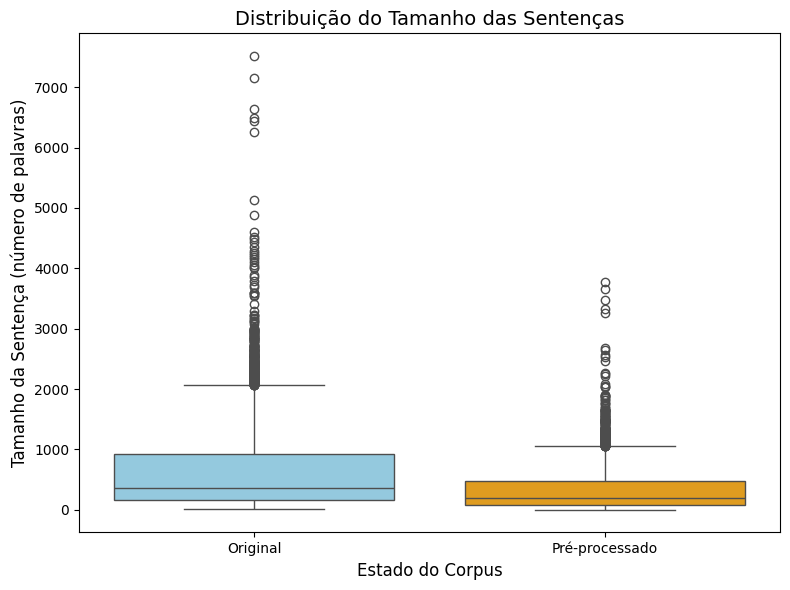

Redução média de tamanho no corpus: 47.3%


In [17]:
# Teste do template: boxplot de tamanho das sentenças no corpus real
if 'num_palavras_texto' not in df.columns:
    df['num_palavras_texto'] = df['texto_completo'].fillna('').astype(str).str.split().str.len()

if 'clean_text' not in df.columns:
    df['clean_text'] = df['texto_completo'].apply(text_cleaning)

df['num_palavras_limpo'] = df['clean_text'].fillna('').astype(str).str.split().str.len()

dados = pd.DataFrame({
    'Tamanho': df['num_palavras_texto'].tolist() + df['num_palavras_limpo'].tolist(),
    'Corpus': ['Original'] * len(df) + ['Pré-processado'] * len(df)
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Corpus', y='Tamanho', data=dados, palette=['skyblue', 'orange'])
plt.title('Distribuição do Tamanho das Sentenças', fontsize=14)
plt.xlabel('Estado do Corpus', fontsize=12)
plt.ylabel('Tamanho da Sentença (número de palavras)', fontsize=12)
plt.tight_layout()
plt.show()

reducao_media_pct = ((df['num_palavras_texto'] - df['num_palavras_limpo']) / df['num_palavras_texto'].replace(0, pd.NA)).mean() * 100
print(f'Redução média de tamanho no corpus: {reducao_media_pct:.1f}%')

## 5. Encerramento e Próxima Fase

A documentação deste notebook foi revisada para restabelecer o contexto metodológico e manter a coerência entre as etapas de preparação do corpus, EDA e pré-processamento.

### Entregáveis consolidados nesta fase
- ambiente Colab e Google Drive configurados;
- corpus consolidado com metadados e rótulos (`label=0` real, `label=1` fake);
- limpeza textual aplicada e comparações de tamanho antes/depois;
- base preparada para modelagem supervisionada.

### Checklist para início da próxima fase (modelagem)
- definir partições de treino, validação e teste com estratificação por classe;
- treinar baseline tradicional (ex.: TF-IDF + classificador linear);
- estabelecer métricas-alvo (F1, precisão, revocação e matriz de confusão);
- preparar pipeline Transformer para comparação justa com o baseline.

### Critério de passagem de fase
Prosseguir para modelagem somente após validar que as colunas usadas no treinamento (texto limpo e `label`) estão sem nulos e alinhadas ao mesmo conjunto de exemplos.

### Model building

In [18]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

print("Tamanho do dataset:", len(df))
print("Número de notícias reais:", (y == 0).sum())
print("Número de fake news:", (y == 1).sum())
print(X, y)


Tamanho do dataset: 7200
Número de notícias reais: 3600
Número de fake news: 3600
0       kátia abreu colocar expulsão moldura reclamar senadora kátia abreu partido to disse expulsão pmdb resultado ação cúpula atual legenda op...
1       dr ray peita bolsonaro chama conservador fake entrevista danilo gentili divide site avisando jair bolsonaro deveria abandonar pauta es...
2       reinaldo azevedo desmascarado polícia federal ferrenho crítico presidenciável jair bolsonaro desmascarado grampo telefônico conversas ir...
3       relatório assustador bndes mostra dinheiro público brasil jorrando países comunistas relatório intitulado bndes transformado robin hood ...
4       radialista americano fala pt vendem ilusão brasileiro pensam divertir sítio radialista americano alex jones chorou falar crianças saúde ...
                                                                           ...                                                                     
7195    jornal britânico ação 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
print(X_train)

2034    maranhão revoga decisão anular sessão impeachment waldir maranhão [presidente exercício câmara] revogou decisão proferida anulava sessõe...
3250    folha sp puxadinho pt recebeu r$ 225 milhões durante gestões petistas ouça jair bolsonaro vídeo abaixo folha dia acabar recebeu r$225 mi...
3366    operação zelotes  mpf denuncia lula corrupção passiva ministério público federal mpf informou luiz inácio lula silva gilberto carvalho ...
1423    renan calheiros reage provocação lindbergh empurrão petista tira mão mim lindbergh pessoa provoca provoca provoca pessoa outro reage sai...
122     temer comandante abin desgrudam acusado utilizar abin vasculhar vida ministro edson fachin presidente temer encontrou chefão abin frequê...
                                                                           ...                                                                     
3772    feira 11 setembro 2017 noite principais notícias terminar dia informado joesley batista jbs dizia gravaç

In [21]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [22]:


# Fit only on training data to avoid data leakage
X_train_tfidf = vectorizer.fit_transform(X_train)
tfidf_terms = vectorizer.get_feature_names_out()
tfidf_idf = pd.Series(vectorizer.idf_, index=tfidf_terms).sort_values(ascending=False)

print(f"Matriz TF-IDF de treino: {X_train_tfidf.shape[0]} documentos x {X_train_tfidf.shape[1]} termos")
print(f"Não zeros na matriz: {X_train_tfidf.nnz}")
print(f"Densidade da matriz: {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.6f}")

Matriz TF-IDF de treino: 5760 documentos x 5000 termos
Não zeros na matriz: 923651
Densidade da matriz: 0.032071


### 4.6. Representação Vetorial com TF-IDF
Esta subseção organiza a leitura do espaço TF-IDF construído apenas com os dados de treino. A sequência abaixo apresenta: a forma compacta da matriz, um heatmap didático, a distribuição dos pesos e, por fim, a projeção 2D do espaço vetorial.

In [23]:
# Prévia compacta da matriz TF-IDF no treino
# Seleciona os 20 termos com maior soma global para uma visualização legível
term_strength = np.asarray(X_train_tfidf.sum(axis=0)).ravel()
top_idx = np.argsort(term_strength)[::-1][:20]

preview_docs = min(5, X_train_tfidf.shape[0])
tfidf_preview_df = pd.DataFrame(
    X_train_tfidf[:preview_docs, top_idx].toarray(),
    columns=tfidf_terms[top_idx]
)

display(tfidf_preview_df)

,presidente,lula,disse,ex,ano,federal,governo,dia,dilma,brasil,temer,país,ministro,ex presidente,jato,lava,acordo,lava jato,pessoas,durante
0,0.089126,0.000000,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.067445,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.000000
1,0.000000,0.000000,0.0,0.00000,0.000000,0.060334,0.107284,0.056538,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.06573,0.0,0.0,0.112846
2,0.000000,0.163795,0.0,0.11675,0.049418,0.057293,0.000000,0.000000,0.075893,0.000000,0.000000,0.060673,0.115582,0.0,0.0,0.000000,0.00000,0.0,0.0,0.000000
3,0.087110,0.000000,0.0,0.00000,0.053357,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.000000
4,0.072164,0.000000,0.0,0.00000,0.000000,0.051247,0.112949,0.000000,0.000000,0.000000,0.177364,0.000000,0.128142,0.0,0.0,0.064759,0.00000,0.0,0.0,0.118804


#### 4.6.1. Prévia Compacta da Matriz TF-IDF
A tabela abaixo mostra uma amostra pequena da matriz vetorial para evidenciar como os textos de treino são convertidos em pesos numéricos por termo.

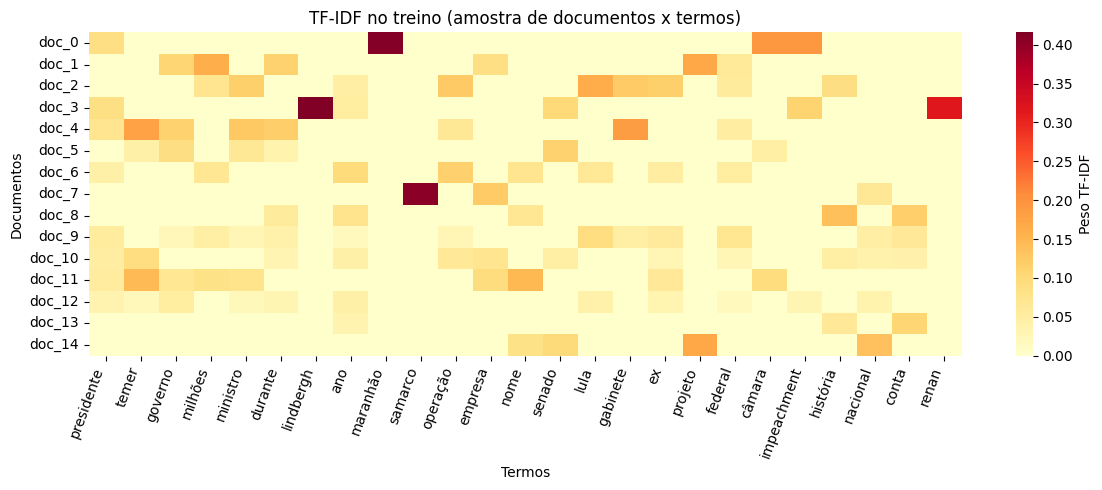

In [24]:
# Heatmap didático: amostra pequena de documentos x termos
n_docs = min(15, X_train_tfidf.shape[0])

# Reusa os termos mais fortes da amostra para manter a leitura visual
sample_matrix = X_train_tfidf[:n_docs]
term_strength = np.asarray(sample_matrix.sum(axis=0)).ravel()
top_idx = np.argsort(term_strength)[::-1][:25]

heat_data = sample_matrix[:, top_idx].toarray()
heat_terms = tfidf_terms[top_idx]

plt.figure(figsize=(12, 5))
sns.heatmap(
    heat_data,
    cmap='YlOrRd',
    cbar_kws={'label': 'Peso TF-IDF'},
    xticklabels=heat_terms,
    yticklabels=[f'doc_{i}' for i in range(n_docs)]
)
plt.title('TF-IDF no treino (amostra de documentos x termos)')
plt.xlabel('Termos')
plt.ylabel('Documentos')
plt.xticks(rotation=70, ha='right')
plt.tight_layout()
plt.show()

#### 4.6.2. Heatmap Didático da Amostra
O heatmap destaca, em poucos documentos, como certos termos recebem peso maior ou menor conforme a presença no texto e a raridade no corpus.

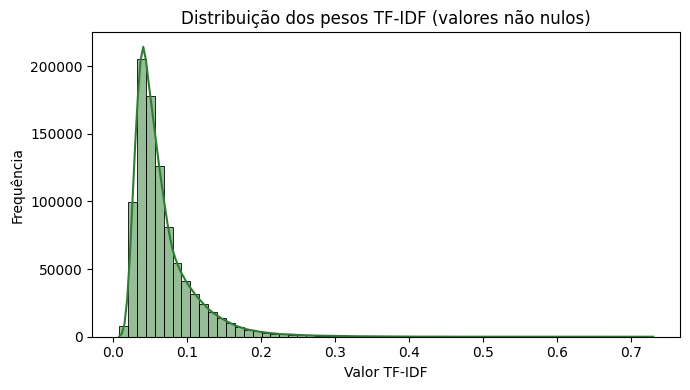

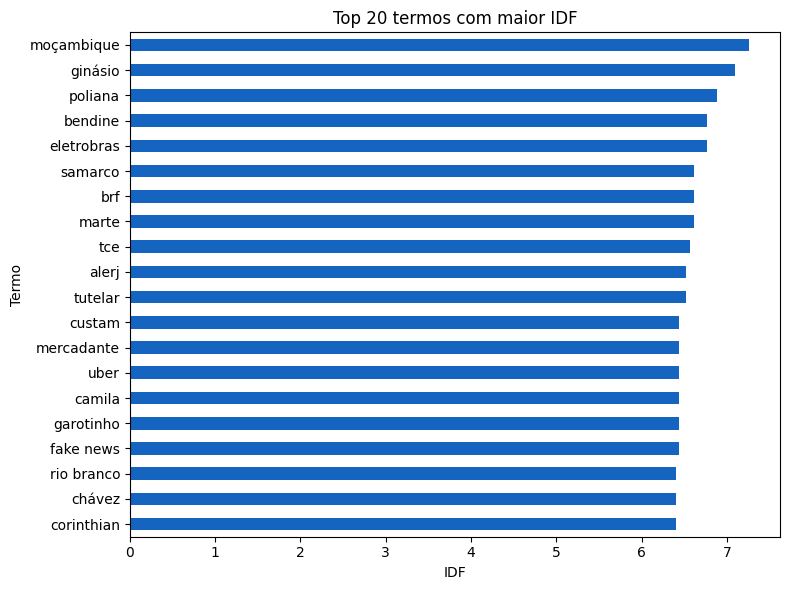

In [25]:
# Distribuição dos pesos TF-IDF não nulos
plt.figure(figsize=(7, 4))
sns.histplot(X_train_tfidf.data, bins=60, kde=True, color='#2E7D32')
plt.title('Distribuição dos pesos TF-IDF (valores não nulos)')
plt.xlabel('Valor TF-IDF')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

# Top termos por IDF: termos raros tendem a ganhar mais peso
fig, ax = plt.subplots(figsize=(8, 6))
tfidf_idf.head(20).sort_values().plot(kind='barh', ax=ax, color='#1565C0')
ax.set_title('Top 20 termos com maior IDF')
ax.set_xlabel('IDF')
ax.set_ylabel('Termo')
plt.tight_layout()

plt.show()

#### 4.6.3. Distribuição dos Pesos e Termos Mais Raros
Nesta parte, a distribuição dos valores TF-IDF mostra a esparsidade da representação, enquanto o gráfico de IDF evidencia os termos raros que tendem a carregar mais informação.

#### 4.6.4. Projeção 2D do Espaço Vetorial
A projeção abaixo resume o espaço TF-IDF em duas dimensões latentes, permitindo observar agrupamentos e sobreposições entre as classes Real e Fake.

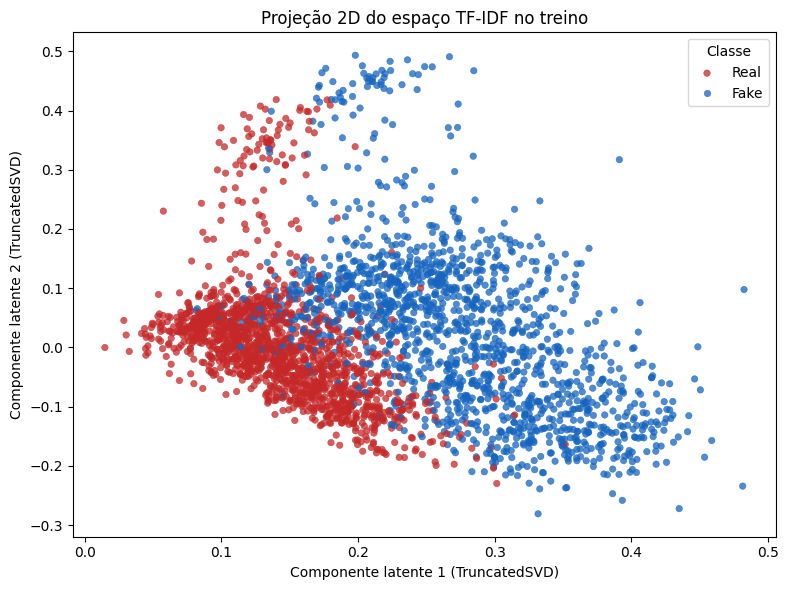

Variância explicada acumulada: 0.0243


In [26]:
from sklearn.decomposition import TruncatedSVD

# TruncatedSVD é mais adequado que PCA para a matriz TF-IDF esparsa
max_docs_proj = min(3000, X_train_tfidf.shape[0])
X_proj_source = X_train_tfidf[:max_docs_proj]

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_proj_source)

plt.figure(figsize=(8, 6))
if y_train is not None and len(y_train) >= max_docs_proj:
    y_proj = np.asarray(y_train)[:max_docs_proj]
    sns.scatterplot(
        x=X_2d[:, 0],
        y=X_2d[:, 1],
        hue=y_proj,
        palette={0: '#1565C0', 1: '#C62828'},
        s=22,
        alpha=0.75,
        edgecolor=None
    )
    plt.legend(title='Classe', labels=['Real', 'Fake'], loc='best')
else:
    plt.scatter(X_2d[:, 0], X_2d[:, 1], s=18, alpha=0.7, color='#1565C0')

plt.title('Projeção 2D do espaço TF-IDF no treino')
plt.xlabel('Componente latente 1 (TruncatedSVD)')
plt.ylabel('Componente latente 2 (TruncatedSVD)')
plt.tight_layout()
plt.show()

print(f'Variância explicada acumulada: {svd.explained_variance_ratio_.sum():.4f}')

### 5.1. Classificação Supervisionada com TF-IDF (Baseline)

Este bloco implementa e avalia dois classificadores lineares para o problema binário **Real (`label=0`) vs Fake (`label=1`)** usando a representação vetorial TF-IDF já ajustada no conjunto de treino.

#### Objetivo
Comparar o desempenho de modelos clássicos de NLP/ML com foco em uma linha de base reprodutível para a etapa de modelagem.

#### Etapas executadas

1. **Transformação do conjunto de teste**
  - `X_test_tfidf = vectorizer.transform(X_test)`
  - Garante o uso do **mesmo vocabulário aprendido no treino**, evitando vazamento de dados.

2. **Treinamento e avaliação do `LinearSVC`**
  - Ajusta o modelo com `X_train_tfidf` e `y_train`.
  - Gera predições em `X_test_tfidf`.
  - Reporta:
    - `classification_report` (precisão, revocação, F1-score por classe),
    - `accuracy_score`.

3. **Treinamento e avaliação da `LogisticRegression`**
  - Ajustada com `solver="liblinear"` e `max_iter=1000`.
  - Mesmo protocolo de avaliação do SVC para comparação justa.

#### Métricas de interesse
- **Acurácia**: desempenho global.
- **Precisão / Revocação / F1**: análise por classe (`Real`, `Fake`), especialmente útil em cenários com possível desbalanceamento.
- **Matriz de confusão** (células seguintes): interpretação de erros de classificação entre classes.

#### Observações
- O notebook também inclui uma alternativa com `Pipeline(TfidfVectorizer + LinearSVC)`, que encapsula vetorização e classificador em uma única estrutura.
- Para manter comparabilidade entre experimentos, utilize sempre o mesmo split (`random_state=42`) e o mesmo pré-processamento textual (`clean_text`).

In [27]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

print("## Classificação Binária (Real vs Fake) com TF-IDF")

# Garante transformação do conjunto de teste com o mesmo vetorizador treinado
X_test_tfidf = vectorizer.transform(X_test)


# 1) Linear SVC
modelo_svc = LinearSVC()
modelo_svc.fit(X_train_tfidf, y_train)
pred_svc = modelo_svc.predict(X_test_tfidf)

print("\n### Linear SVC")
print(classification_report(y_test, pred_svc, target_names=["Real", "Fake"]))
print(f"Acurácia (Linear SVC): {accuracy_score(y_test, pred_svc):.4f}")

# 2) Logistic Regression

modelo_lr = LogisticRegression(max_iter=1000, solver="liblinear")
modelo_lr.fit(X_train_tfidf, y_train)
pred_lr = modelo_lr.predict(X_test_tfidf)

print("\n### Logistic Regression")
print(classification_report(y_test, pred_lr, target_names=["Real", "Fake"]))
print(f"Acurácia (Logistic Regression): {accuracy_score(y_test, pred_lr):.4f}")

## Classificação Binária (Real vs Fake) com TF-IDF

### Linear SVC
              precision    recall  f1-score   support

        Real       0.97      0.97      0.97       722
        Fake       0.97      0.97      0.97       718

    accuracy                           0.97      1440
   macro avg       0.97      0.97      0.97      1440
weighted avg       0.97      0.97      0.97      1440

Acurácia (Linear SVC): 0.9667

### Logistic Regression
              precision    recall  f1-score   support

        Real       0.97      0.95      0.96       722
        Fake       0.95      0.97      0.96       718

    accuracy                           0.96      1440
   macro avg       0.96      0.96      0.96      1440
weighted avg       0.96      0.96      0.96      1440

Acurácia (Logistic Regression): 0.9597


In [28]:
from sklearn.svm import LinearSVC
clf = LinearSVC()
clf.fit(X_train_tfidf, y_train)

LinearSVC()

In [29]:

from sklearn.pipeline import Pipeline
text_clf = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('clf', LinearSVC())
])
text_clf.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=5000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf', LinearSVC())])

In [30]:
predictions = text_clf.predict(X_test)

In [31]:
from sklearn import metrics
print(metrics.classification_report(y_test, predictions, target_names=['Real', 'Fake']))

              precision    recall  f1-score   support

        Real       0.97      0.97      0.97       722
        Fake       0.97      0.97      0.97       718

    accuracy                           0.97      1440
   macro avg       0.97      0.97      0.97      1440
weighted avg       0.97      0.97      0.97      1440



In [32]:
print(metrics.accuracy_score(y_test, predictions))

0.9666666666666667


In [33]:
print(metrics.confusion_matrix(y_test, predictions))

[[698  24]
 [ 24 694]]
